**Датасет:** https://www.kaggle.com/datasets/camnugent/sandp500

# Лабораторная работа 1. Линейная регрессия и факторный анализ

Дневные цены акций индекса S&P 500. Локальная копия: `data/sp500_5yr.csv`.

## Введение

Цель — по дневным ценам и объёму торгов предсказать цену закрытия следующего дня, проверить мультиколлинеарность и сравнить модель на главных компонентах.

Задачи:

1. Описать котировки и их распределения.
2. Убрать пропуски, собрать цель «закрытие завтра», разделить выборку 80/20 и стандартизировать признаки.
3. Построить корреляции и VIF.
4. Обучить линейную, гребневую и лассо-регрессию с кросс-валидацией. Метрики: RMSE, R², MAPE.
5. Провести PCA и повторить три модели.

Цель — цена в долларах, она непрерывная. Логистическая регрессия не нужна.


## Описание датасета

Набор Cam Nugent на Kaggle: торговые дни 505 акций S&P 500 с 8 февраля 2013 по 7 февраля 2018. В файле 619040 строк и 7 столбцов.


In [1]:
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import statsmodels
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42
ALPHAS = np.logspace(-4, 2, 10)
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
FEATURES = ["open", "high", "low", "close", "volume"]
TARGET = "next_close"
LABELS = {
    "open": "Открытие",
    "high": "Максимум",
    "low": "Минимум",
    "close": "Закрытие",
    "volume": "Объём",
    "next_close": "Закрытие завтра",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.family": "DejaVu Sans",
    "axes.unicode_minus": False,
})


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    mape = float(np.mean(np.abs(y_true - y_pred) / np.abs(y_true)) * 100)
    return {"RMSE": rmse, "R²": r2, "MAPE, %": mape}


def make_model(kind, alpha=None):
    if kind == "Линейная":
        return LinearRegression()
    if kind == "Гребневая":
        if alpha is None:
            return RidgeCV(alphas=ALPHAS, cv=3)
        return Ridge(alpha=alpha)
    if kind == "Лассо":
        if alpha is None:
            return LassoCV(alphas=ALPHAS, cv=3, max_iter=20000, random_state=RANDOM_STATE)
        return Lasso(alpha=alpha, max_iter=20000)
    raise ValueError(kind)


def score_model(kind, feature_space, n_components=None):
    def steps(alpha=None):
        sequence = [("scaler", StandardScaler())]
        if n_components is not None:
            sequence.append(("pca", PCA(n_components=n_components)))
        sequence.append(("model", make_model(kind, alpha)))
        return sequence

    selector = Pipeline(steps())
    selector.fit(X_train, y_train)
    alpha = getattr(selector.named_steps["model"], "alpha_", None)
    pipeline = Pipeline(steps(alpha))
    pipeline.fit(X_train, y_train)
    test_m = regression_metrics(y_test, pipeline.predict(X_test))
    train_r2 = float(r2_score(y_train, pipeline.predict(X_train)))
    cv_result = cross_validate(
        Pipeline(steps(alpha)),
        X_train,
        y_train,
        cv=CV,
        scoring={
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
            "MAPE": "neg_mean_absolute_percentage_error",
        },
    )
    row = {
        "Модель": kind,
        "Признаки": feature_space,
        "RMSE": test_m["RMSE"],
        "R²": test_m["R²"],
        "MAPE, %": test_m["MAPE, %"],
        "CV RMSE": float((-cv_result["test_RMSE"]).mean()),
        "CV R²": float(cv_result["test_R2"].mean()),
        "CV MAPE, %": float((-cv_result["test_MAPE"]).mean() * 100),
        "α": float(alpha) if alpha is not None and np.isfinite(alpha) else np.nan,
        "R² train": train_r2,
    }
    return row, pipeline


def show_metrics(frame):
    view = frame.copy()
    view["α"] = view["α"].map(lambda v: "—" if pd.isna(v) else f"{v:.3g}")
    numeric = [c for c in view.columns if c not in ("Модель", "Признаки", "α")]
    fmt = {c: ("{:.4f}" if "R²" in c else "{:.3f}") for c in numeric}
    display(view.style.format(fmt).hide(axis="index"))


raw = pd.read_csv(Path("data") / "sp500_5yr.csv", parse_dates=["date"])
print(f"Строк: {len(raw)}, столбцов: {raw.shape[1]}")
print(f"Акций: {raw['Name'].nunique()}")
print(f"Даты: {raw['date'].min().date()} — {raw['date'].max().date()}")
print(f"pandas {pd.__version__}, scikit-learn {sklearn.__version__}")
display(raw.head())


Строк: 619040, столбцов: 7
Акций: 505
Даты: 2013-02-08 — 2018-02-07
pandas 2.2.3, scikit-learn 1.7.1


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


Каждая строка — один тикер в один торговый день. `open`, `high`, `low` и `close` — цены в долларах, `volume` — число акций в сделках, `Name` — тикер.

Имя акции в регрессию не входит: уровней 505, это метка бумаги, а не свойство торгового дня.


### Пропуски и масштаб


In [2]:
summary = raw[["open", "high", "low", "close", "volume"]].describe().T
summary["пропуски"] = raw[["open", "high", "low", "close", "volume"]].isna().sum()
summary["асимметрия"] = raw[["open", "high", "low", "close", "volume"]].skew()
summary.index = [LABELS[name] for name in summary.index]
display(summary.round(2))
print(f"Пропусков всего: {int(raw.isna().sum().sum())}")
print(f"Полных дублей: {int(raw.duplicated().sum())}")


,count,mean,std,min,25%,50%,75%,max,пропуски,асимметрия
Открытие,619029.0,83.02,97.38,1.62,40.22,62.59,94.37,2.044000e+03,11,7.66
Максимум,619032.0,83.78,98.21,1.69,40.62,63.15,95.18,2.067990e+03,8,7.65
Минимум,619032.0,82.26,96.51,1.50,39.83,62.02,93.54,2.035110e+03,8,7.67
Закрытие,619040.0,83.04,97.39,1.59,40.24,62.62,94.41,2.049000e+03,0,7.66
Объём,619040.0,4321823.40,8693609.51,0.00,1070320.50,2082093.50,4284509.25,6.182376e+08,0,10.28


Пропусков всего: 27


Полных дублей: 0


Пропусков мало: 11 в цене открытия и по 8 в максимуме и минимуме. Дублей нет.

Цены скошены вправо (асимметрия около 7,7): большинство бумаг стоит до 100 долларов, отдельные — больше 1000. Объём ещё сильнее прижат к небольшим значениям. Перед регрессией со штрафом и перед PCA столбцы нужно стандартизировать.


### Распределения


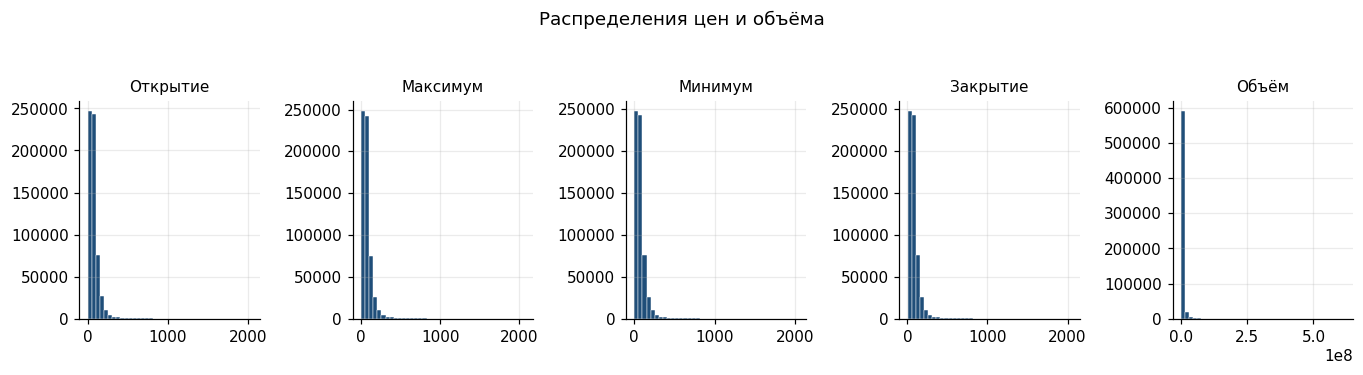

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(12.5, 3.2))
for ax, column in zip(axes, FEATURES):
    ax.hist(raw[column].dropna(), bins=40, color="#1f4e79", edgecolor="white", linewidth=0.3)
    ax.set_title(LABELS[column], fontsize=10)
fig.suptitle("Распределения цен и объёма", y=1.05)
fig.tight_layout()
plt.show()


Четыре цены выглядят одинаково: это один и тот же уровень бумаги, снятый в разные моменты дня. Объём — отдельная величина, у него длинный правый хвост крупных сделок.


### Цель: закрытие следующего дня

Для каждой акции цена закрытия сдвигается на один торговый день вперёд. Последний день ряда цели не имеет и выпадает из выборки.


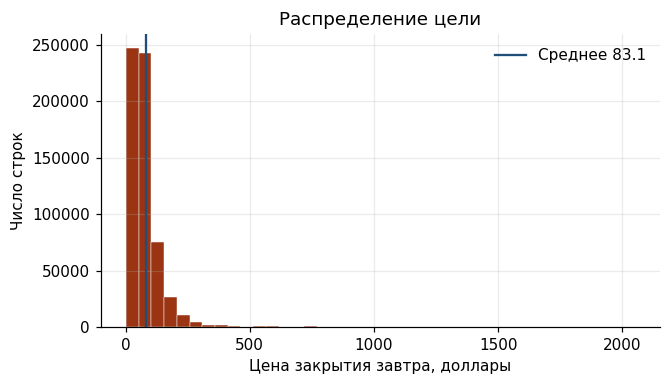

Строк в рабочей выборке: 618524
Минимум 1.59, максимум 2049


In [4]:
ordered = raw.sort_values(["Name", "date"]).copy()
ordered[TARGET] = ordered.groupby("Name")["close"].shift(-1)
data = ordered.dropna().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.hist(data[TARGET], bins=40, color="#9a3412", edgecolor="white", linewidth=0.3)
ax.axvline(data[TARGET].mean(), color="#1f4e79", label=f"Среднее {data[TARGET].mean():.1f}")
ax.set_xlabel("Цена закрытия завтра, доллары")
ax.set_ylabel("Число строк")
ax.set_title("Распределение цели")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Строк в рабочей выборке: {len(data)}")
print(f"Минимум {data[TARGET].min():.2f}, максимум {data[TARGET].max():.0f}")


После удаления пропусков и последних дней остаётся 618524 строки. Средняя завтрашняя цена около 83 долларов, максимум около 2000. Ноль в цели не встречается, поэтому MAPE считать можно.

Высокая точность такой модели ещё не означает торговую стратегию: завтрашняя цена почти равна сегодняшней. Это проверяется ниже.


### Связь со сегодняшним закрытием


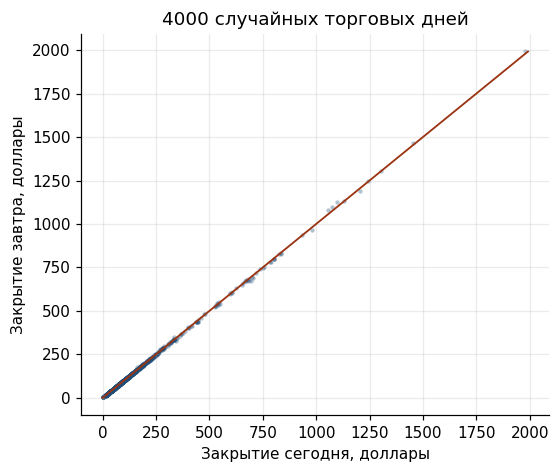

In [5]:
sample = data.sample(4000, random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(sample["close"], sample[TARGET], s=8, alpha=0.35, color="#1f4e79", linewidths=0)
limit = [0, max(sample["close"].max(), sample[TARGET].max())]
ax.plot(limit, limit, color="#9a3412", linewidth=1.2)
ax.set_xlabel("Закрытие сегодня, доллары")
ax.set_ylabel("Закрытие завтра, доллары")
ax.set_title("4000 случайных торговых дней")
fig.tight_layout()
plt.show()


Точки лежат на диагонали. День меняет цену мало по сравнению с различием между дешёвыми и дорогими акциями. Поэтому любой признак, который несёт сегодняшний уровень цены, уже почти определяет цель.


## Подготовка данных

Признаки модели: открытие, максимум, минимум, закрытие и объём текущего дня. Цель уже собрана. Выборка делится 80/20. Стандартизация стоит внутри пайплайна и на фолдах считается заново.


In [6]:
X = data[FEATURES]
y = data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Обучение: {len(X_train)}")
print(f"Тест: {len(X_test)}")
print(f"Среднее цели, train / test: {y_train.mean():.2f} / {y_test.mean():.2f}")
print(f"Ст. отклонение, train / test: {y_train.std():.2f} / {y_test.std():.2f}")


Обучение: 494819
Тест: 123705
Среднее цели, train / test: 82.98 / 83.41
Ст. отклонение, train / test: 96.99 / 99.08


В обучении 494819 строк, в тесте 123705. Категорий нет, кодировать нечего.

Разбиение случайное по строкам, как требует постановка. Соседние дни одной акции могут попасть в разные части. Метрика показывает, насколько модель восстанавливает уровень цены, а не прогноз на совершенно новый период.


## Ход работы

### Корреляции


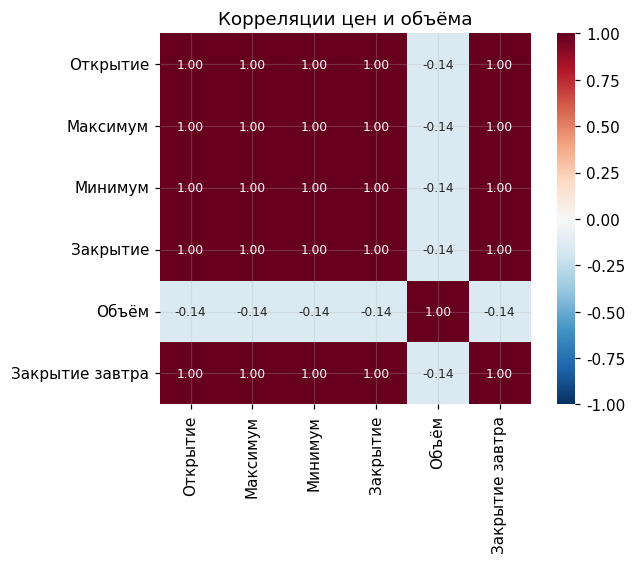

In [7]:
cols = FEATURES + [TARGET]
corr = data[cols].corr()
corr.index = [LABELS[name] for name in corr.index]
corr.columns = [LABELS[name] for name in corr.columns]

fig, ax = plt.subplots(figsize=(6.4, 5.2))
sns.heatmap(
    corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 8}, square=True,
)
ax.set_title("Корреляции цен и объёма")
fig.tight_layout()
plt.show()


Открытие, максимум, минимум, закрытие и завтрашнее закрытие коррелируют между собой на 1,00 с точностью до двух знаков. Объём с ценой связан слабо, около −0,14. Четыре цены — повторы одного уровня, а не четыре разных фактора.


### VIF

VIF считается на стандартизированных признаках обучающей выборки. Выше 10 — сильная мультиколлинеарность.


Признак,VIF
Максимум,21548.9
Закрытие,19944.7
Минимум,19099.0
Открытие,17977.3
Объём,1.0


Число обусловленности: 492


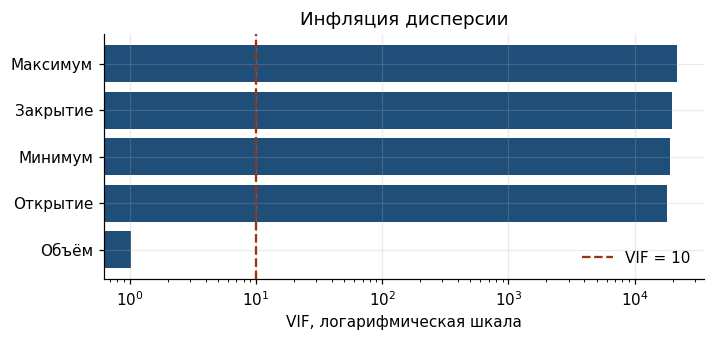

In [8]:
design = StandardScaler().fit_transform(X_train)
design_const = add_constant(design)
vif = pd.DataFrame({
    "Признак": [LABELS[name] for name in FEATURES],
    "VIF": [variance_inflation_factor(design_const, i) for i in range(1, design_const.shape[1])],
}).sort_values("VIF", ascending=False)
display(vif.style.format({"VIF": "{:.1f}"}).hide(axis="index"))
print(f"Число обусловленности: {np.linalg.cond(design):.0f}")

fig, ax = plt.subplots(figsize=(6.6, 3.2))
order = vif.sort_values("VIF")
ax.barh(order["Признак"], order["VIF"], color="#1f4e79")
ax.set_xscale("log")
ax.axvline(10, color="#9a3412", linestyle="--", label="VIF = 10")
ax.set_xlabel("VIF, логарифмическая шкала")
ax.set_title("Инфляция дисперсии")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


VIF четырёх цен — от 18 до 22 тысяч. Объём имеет VIF около 1 и в этой зависимости не участвует. Число обусловленности матрицы около 490.

Коэффициенты при открытии, максимуме и минимуме по отдельности читать нельзя: они делят между собой один и тот же ценовой уровень. Для прогноза это не мешает, для интерпретации — мешает. PCA ниже собирает уровень цены в одну компоненту.


### Три регрессии

Линейная модель минимизирует сумму квадратов. Гребневая добавляет \(\alpha\|\beta\|_2^2\), лассо — \(\alpha\|\beta\|_1\). Штраф выбирается кросс-валидацией на обучении. Затем с выбранным \(\alpha\) делается внешняя проверка на 5 фолдах.

RMSE — в долларах. MAPE — в процентах от фактической завтрашней цены.


In [9]:
KINDS = ["Линейная", "Гребневая", "Лассо"]
rows = []
fitted = {}
for kind in KINDS:
    row, pipeline = score_model(kind, "Исходные")
    rows.append(row)
    fitted[kind] = pipeline

metrics_original = pd.DataFrame(rows)
show_metrics(metrics_original)
coef = pd.Series(fitted["Линейная"].named_steps["model"].coef_, index=[LABELS[c] for c in FEATURES])
print(f"Свободный член: {fitted['Линейная'].named_steps['model'].intercept_:.2f} доллара")
lasso_coef = fitted["Лассо"].named_steps["model"].coef_
print(f"Нулевых коэффициентов лассо: {int(np.sum(np.abs(lasso_coef) < 1e-6))} из {len(lasso_coef)}")


Модель,Признаки,RMSE,R²,"MAPE, %",CV RMSE,CV R²,"CV MAPE, %",α,R² train
Линейная,Исходные,2.070,0.9996,1.064,1.900,0.9996,1.067,—,0.9996
Гребневая,Исходные,2.070,0.9996,1.064,1.900,0.9996,1.067,0.01,0.9996
Лассо,Исходные,2.086,0.9996,1.078,1.915,0.9996,1.081,0.0001,0.9996


Свободный член: 82.98 доллара
Нулевых коэффициентов лассо: 0 из 5


Линейная модель на тесте: RMSE 2,07 доллара, R² 0,9996, MAPE 1,06%. Гребневая даёт те же цифры. Лассо чуть слабее: RMSE 2,09 доллара и MAPE 1,08%. Выбранный штраф — нижний край сетки, 0,0001, поэтому ни один столбец не выбрасывается.

Кросс-валидация линейной модели: RMSE около 1,90 доллара, R² 0,9996, MAPE около 1,07%. R² на обучении тоже 0,9996. Разрыва переобучения нет.

Такой R² держится на инерции цены. Ошибка в 2 доллара при средней цене 83 доллара — это около одного дневного шага, а не «угадывание рынка».


### Коэффициенты


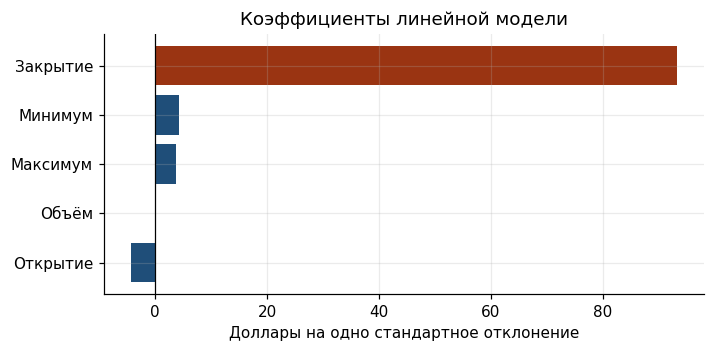

,Коэффициент
Открытие,-4.30
Максимум,3.72
Минимум,4.34
Закрытие,93.21
Объём,0.01


In [10]:
fig, ax = plt.subplots(figsize=(6.6, 3.3))
ordered_coef = coef.sort_values()
colors = ["#9a3412" if name == "Закрытие" else "#1f4e79" for name in ordered_coef.index]
ax.barh(ordered_coef.index, ordered_coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Доллары на одно стандартное отклонение")
ax.set_title("Коэффициенты линейной модели")
fig.tight_layout()
plt.show()
display(coef.round(2).rename("Коэффициент").to_frame())


Закрытие получает около +93 долларов на одно стандартное отклонение. Открытие, максимум и минимум остаются небольшими и не читаются поодиночке: их VIF измеряется десятками тысяч. Объём в линейной модели почти нулевой. При таком VIF знак и величина трёх «лишних» цен неустойчивы, устойчив только общий уровень.

Свободный член около 83 долларов — это средний уровень цены при средних стандартизированных признаках.


### Факт и прогноз


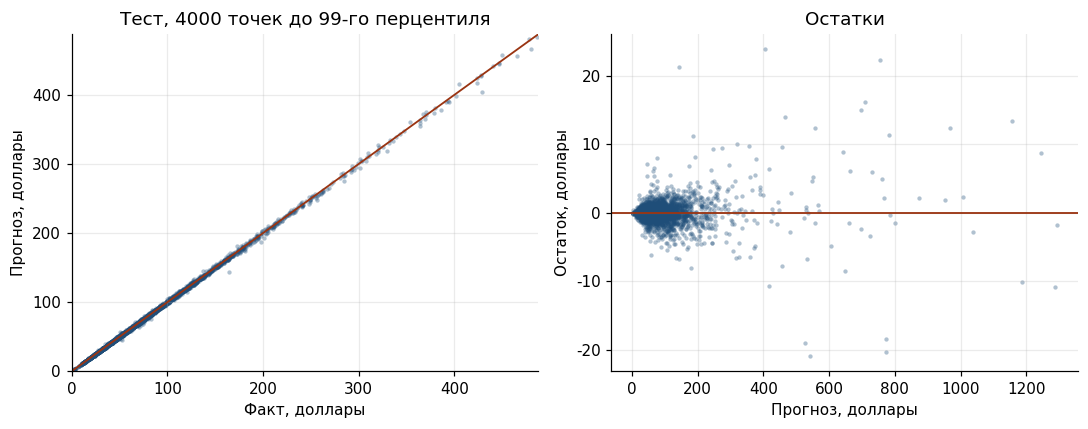

Средний остаток: 0.006 доллара
Доля |остатка| > 5 долларов: 1.7%


In [11]:
pred = fitted["Линейная"].predict(X_test)
resid = y_test.to_numpy() - pred
show = np.random.default_rng(RANDOM_STATE).choice(len(pred), size=4000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_test.to_numpy()[show], pred[show], s=8, alpha=0.35, color="#1f4e79", linewidths=0)
lim = [0, np.quantile(y_test, 0.99)]
axes[0].plot(lim, lim, color="#9a3412", linewidth=1.2)
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_xlabel("Факт, доллары")
axes[0].set_ylabel("Прогноз, доллары")
axes[0].set_title("Тест, 4000 точек до 99-го перцентиля")

axes[1].scatter(pred[show], resid[show], s=8, alpha=0.35, color="#1f4e79", linewidths=0)
axes[1].axhline(0, color="#9a3412", linewidth=1.2)
axes[1].set_xlabel("Прогноз, доллары")
axes[1].set_ylabel("Остаток, доллары")
axes[1].set_title("Остатки")
fig.tight_layout()
plt.show()
print(f"Средний остаток: {resid.mean():.3f} доллара")
print(f"Доля |остатка| > 5 долларов: {(np.abs(resid) > 5).mean():.1%}")


Прогноз повторяет факт вдоль диагонали. Средний остаток на тесте 0,006 доллара. Абсолютная ошибка больше 5 долларов только у 1,7% строк. У дорогих бумаг долларовый промах больше, в процентах ошибка остаётся около 1%.


### PCA

Признаки снова стандартизируются, затем строится PCA только по обучению. Порог — 95% дисперсии. Рядом смотрю критерий Кайзера: собственные значения не меньше 1.


Кайзер: 1 компонента, дисперсия 80.5%
Порог 95%: 2 компоненты, дисперсия 100.0%
PC1: λ = 4.027, доля 80.5%, накоплено 80.5%
PC2: λ = 0.973, доля 19.5%, накоплено 100.0%
PC3: λ = 0.000, доля 0.0%, накоплено 100.0%
PC4: λ = 0.000, доля 0.0%, накоплено 100.0%
PC5: λ = 0.000, доля 0.0%, накоплено 100.0%


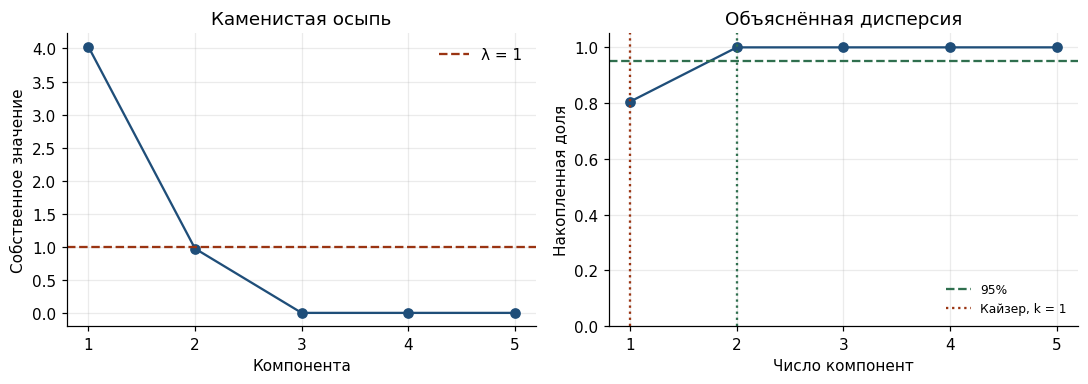

In [12]:
pca_full = PCA().fit(design)
eigen = pca_full.explained_variance_
share = pca_full.explained_variance_ratio_
cumulative = np.cumsum(share)
index = np.arange(1, len(eigen) + 1)
K_KAISER = int(np.sum(eigen >= 1))
K_95 = int(np.argmax(cumulative >= 0.95) + 1)

print(f"Кайзер: {K_KAISER} компонента, дисперсия {cumulative[K_KAISER - 1]:.1%}")
print(f"Порог 95%: {K_95} компоненты, дисперсия {cumulative[K_95 - 1]:.1%}")
for i, (value, part, cum) in enumerate(zip(eigen, share, cumulative), start=1):
    print(f"PC{i}: λ = {value:.3f}, доля {part:.1%}, накоплено {cum:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(index, eigen, marker="o", color="#1f4e79")
axes[0].axhline(1, color="#9a3412", linestyle="--", label="λ = 1")
axes[0].set_xlabel("Компонента")
axes[0].set_ylabel("Собственное значение")
axes[0].set_title("Каменистая осыпь")
axes[0].set_xticks(index)
axes[0].legend(frameon=False)

axes[1].plot(index, cumulative, marker="o", color="#1f4e79")
axes[1].axhline(0.95, color="#2f6f4e", linestyle="--", label="95%")
axes[1].axvline(K_95, color="#2f6f4e", linestyle=":")
axes[1].axvline(K_KAISER, color="#9a3412", linestyle=":", label=f"Кайзер, k = {K_KAISER}")
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Накопленная доля")
axes[1].set_title("Объяснённая дисперсия")
axes[1].set_xticks(index)
axes[1].set_ylim(0, 1.05)
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


Осыпь обрывается после второй компоненты. Первая забирает около 80% дисперсии, вместе со второй — практически 100%. Дальше собственные значения нулевые: это числовой шум от почти одинаковых цен.

Критерий Кайзера оставляет 1 компоненту. Порог 95% — 2 компоненты. Для прогноза беру две.


### Что внутри компонент


In [13]:
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=[LABELS[name] for name in FEATURES],
    columns=["PC1", "PC2"],
)
display(loadings.round(2))

pcs = PCA(n_components=K_95).fit_transform(design)
pc_vif = [variance_inflation_factor(add_constant(pcs), i) for i in range(1, K_95 + 1)]
print(f"Максимальный VIF {K_95} компонент: {max(pc_vif):.3f}")
print(f"Число обусловленности компонент: {np.linalg.cond(pcs):.2f}")


,PC1,PC2
Открытие,0.50,0.05
Максимум,0.50,0.05
Минимум,0.50,0.05
Закрытие,0.50,0.05
Объём,-0.09,1.00


Максимальный VIF 2 компонент: 1.000
Число обусловленности компонент: 2.03


PC1 — уровень цены: у открытия, максимума, минимума и закрытия нагрузки около 0,50. PC2 — объём, нагрузка около 1.

У двух компонент VIF равен 1. Число обусловленности падает с 492 до 2. Четыре копирующие цены сжаты в один фактор.


### Модели на компонентах


In [14]:
pca_rows = []
for k, space in ((K_95, f"PCA 95% ({K_95})"), (K_KAISER, f"PCA Кайзер ({K_KAISER})")):
    for kind in KINDS:
        row, _ = score_model(kind, space, n_components=k)
        pca_rows.append(row)

metrics_pca = pd.DataFrame(pca_rows)
show_metrics(metrics_pca)


Модель,Признаки,RMSE,R²,"MAPE, %",CV RMSE,CV R²,"CV MAPE, %",α,R² train
Линейная,PCA 95% (2),2.216,0.9995,1.165,2.056,0.9996,1.168,—,0.9996
Гребневая,PCA 95% (2),2.216,0.9995,1.165,2.056,0.9996,1.168,1,0.9996
Лассо,PCA 95% (2),2.216,0.9995,1.165,2.056,0.9996,1.168,0.000464,0.9996
Линейная,PCA Кайзер (1),5.070,0.9974,6.372,4.954,0.9974,6.257,—,0.9974
Гребневая,PCA Кайзер (1),5.070,0.9974,6.372,4.954,0.9974,6.257,0.215,0.9974
Лассо,PCA Кайзер (1),5.070,0.9974,6.372,4.954,0.9974,6.257,0.00215,0.9974


На двух компонентах линейная модель даёт RMSE около 2,22 доллара, R² 0,9995 и MAPE около 1,17%. Это близко к исходным пяти признакам.

Одна компонента Кайзера грубее: RMSE около 5,07 доллара, R² 0,997 и MAPE около 6,4%. В ней остаётся только общий уровень цены, без объёма и без мелких различий между открытием и закрытием.


### Сравнение


Модель,Признаки,RMSE,R²,"MAPE, %",CV RMSE,CV R²,"CV MAPE, %",α,R² train
Линейная,Исходные,2.070,0.9996,1.064,1.900,0.9996,1.067,—,0.9996
Гребневая,Исходные,2.070,0.9996,1.064,1.900,0.9996,1.067,0.01,0.9996
Лассо,Исходные,2.086,0.9996,1.078,1.915,0.9996,1.081,0.0001,0.9996
Линейная,PCA 95% (2),2.216,0.9995,1.165,2.056,0.9996,1.168,—,0.9996
Гребневая,PCA 95% (2),2.216,0.9995,1.165,2.056,0.9996,1.168,1,0.9996
Лассо,PCA 95% (2),2.216,0.9995,1.165,2.056,0.9996,1.168,0.000464,0.9996
Линейная,PCA Кайзер (1),5.070,0.9974,6.372,4.954,0.9974,6.257,—,0.9974
Гребневая,PCA Кайзер (1),5.070,0.9974,6.372,4.954,0.9974,6.257,0.215,0.9974
Лассо,PCA Кайзер (1),5.070,0.9974,6.372,4.954,0.9974,6.257,0.00215,0.9974


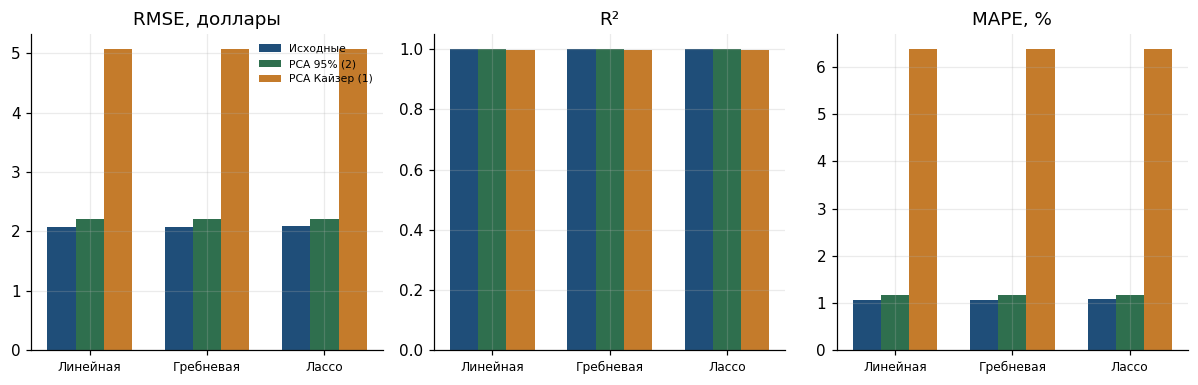

2 компоненты против исходных: ΔRMSE +0.146 доллара, ΔR² -0.0001, ΔMAPE +0.101 п.п.


In [15]:
metrics_all = pd.concat([metrics_original, metrics_pca], ignore_index=True)
show_metrics(metrics_all)

colors = {
    "Исходные": "#1f4e79",
    f"PCA 95% ({K_95})": "#2f6f4e",
    f"PCA Кайзер ({K_KAISER})": "#c47b2b",
}
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
x = np.arange(len(KINDS))
width = 0.24
for ax, column, title in zip(axes, ["RMSE", "R²", "MAPE, %"], ["RMSE, доллары", "R²", "MAPE, %"]):
    for i, (space, color) in enumerate(colors.items()):
        part = metrics_all[metrics_all["Признаки"] == space].set_index("Модель").loc[KINDS]
        ax.bar(x + (i - 1) * width, part[column], width=width, color=color, label=space)
    ax.set_xticks(x)
    ax.set_xticklabels(KINDS, fontsize=8)
    ax.set_title(title)
axes[0].legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

base = metrics_original.set_index("Модель").loc["Линейная"]
alt = metrics_pca.set_index(["Признаки", "Модель"]).loc[(f"PCA 95% ({K_95})", "Линейная")]
print(
    f"2 компоненты против исходных: "
    f"ΔRMSE {alt['RMSE'] - base['RMSE']:+.3f} доллара, "
    f"ΔR² {alt['R²'] - base['R²']:+.4f}, "
    f"ΔMAPE {alt['MAPE, %'] - base['MAPE, %']:+.3f} п.п."
)


| Признаки | RMSE, доллары | R² | MAPE, % |
| --- | ---: | ---: | ---: |
| 5 исходных | 2,07 | 0,9996 | 1,06 |
| 2 главные компоненты | 2,22 | 0,9995 | 1,17 |
| 1 компонента Кайзера | 5,07 | 0,9974 | 6,37 |

Две компоненты увеличивают RMSE на 0,15 доллара. Мультиколлинеарность при этом снята. Одна компонента уже заметно грубее: плюс около 3 долларов к ошибке.

Регуляризация тест почти не меняет. Запас точности был не в штрафе, а в том, что завтрашняя цена повторяет сегодняшнюю.


## Заключение

По дневным котировкам S&P 500 линейная регрессия предсказывает завтрашнее закрытие с ошибкой около 2,07 доллара (RMSE), R² 0,9996 и MAPE 1,06%. Гребневая модель совпадает с ней. Лассо остаётся рядом и не выбрасывает признаки: штраф слишком мал.

Четыре цены имеют VIF порядка 20 тысяч: это один фактор уровня. Две главные компоненты, цена и объём, сохраняют почти всё качество. Критерий Кайзера оставляет только цену, и RMSE вырастает до 5,07 доллара.

Высокий R² здесь — следствие инерции котировки, а не найденной торговой закономерности. Случайное разбиение ещё и перемешивает соседние дни. Чтобы искать именно изменение цены, целью должен быть дневной прирост, а не сам уровень. Для прироста около нуля MAPE уже непригоден, поэтому в работе цель оставлена ценой.


## Список источников

1. Nugent C. S&P 500 stock data [Электронный ресурс] // Kaggle. URL: https://www.kaggle.com/datasets/camnugent/sandp500 (дата обращения: 01.10.2026).
2. James G., Witten D., Hastie T., Tibshirani R. An Introduction to Statistical Learning. 2nd ed. New York : Springer, 2021.
3. Jolliffe I. T., Cadima J. Principal component analysis: a review and recent developments // Philosophical Transactions of the Royal Society A. 2016. Vol. 374. 20150202.
4. Документация scikit-learn [Электронный ресурс]. URL: https://scikit-learn.org/stable/ (дата обращения: 01.10.2026).


## Приложение

Полный листинг — ячейки кода этого ноутбука по порядку. Запуск из папки проекта, где лежит `data/sp500_5yr.csv`. Фиксированы `random_state=42`, тест 20% и пять фолдов.
